# 03 · Segmentation: does the graph beat the attribute baseline?

Banks segment merchants by what they know about them: MCC, size, ticket, channel, card mix.
Feature 4 asks whether segmenting them by **who buys from them** works better for pricing.

Three segmentations of the same merchants:

- **baseline** — k-means on the tabular attributes, the industry practice;
- **graph** — k-means on spectral embeddings of the cardholder-merchant graph, where two
  merchants are close when the same cards buy from both;
- **hybrid** — k-means on both blocks at once, which is what a team with a graph would
  actually ship: it answers whether the graph adds anything to what the bank already knows;
- **leiden** — communities of the merchant projection, which chooses its own number of groups.

They are judged on three criteria (spec §2.5): homogeneity of effective interchange, power to
predict the relative burden of a merchant the model has not seen, and interpretability. The
out-of-sample column is the one that decides, and the conclusion is printed either way.

> **Synthetic data.** The generator planted the clienteles this is trying to recover, so the
> comparison shows whether the method finds structure that exists, not that Colombian
> merchants are organised this way. Run `python -m ips.tasks generate` and
> `python -m ips.tasks dbt` first.

In [1]:
import time

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import polars.selectors as cs
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.ticker import PercentFormatter

from ips.graph.baseline_kmeans import feature_matrix
from ips.graph.clustering import cluster_merchants, combine_spaces
from ips.graph.evaluate import out_of_sample, verdict
from ips.graph.pipeline import BASELINE, GRAPH, HYBRID, LEIDEN, run_segmentation
from ips.utils.config import load_config

pl.Config.set_thousands_separator(",")
pl.Config.set_tbl_hide_dataframe_shape(True)
pl.Config.set_tbl_rows(20)
pl.Config.set_tbl_width_chars(180)
pl.Config.set_tbl_cols(14)
pl.Config.set_fmt_str_lengths(60)
start = time.perf_counter()
cfg = load_config()

Chart style: the dataviz reference palette, as in notebooks 01 and 02. Categorical
colours in a fixed order, one blue ramp for magnitude, and the emphasis colour reserved for
the method that wins.

In [2]:
SURFACE, INK, INK_2, MUTED = "#fcfcfb", "#0b0b0b", "#52514e", "#898781"
GRID, AXIS = "#e1e0d9", "#c3c2b7"
SERIES = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100"]  # categorical slots 1-4, fixed order
BLUES = ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95", "#0d366b"]
plt.rcParams.update(
    {
        "figure.facecolor": SURFACE,
        "axes.facecolor": SURFACE,
        "savefig.facecolor": SURFACE,
        "figure.dpi": 110,
        "font.family": "sans-serif",
        "font.size": 10,
        "axes.edgecolor": AXIS,
        "axes.linewidth": 0.8,
        "axes.labelcolor": INK_2,
        "axes.titlecolor": INK,
        "axes.titlesize": 12,
        "axes.titleweight": "bold",
        "axes.axisbelow": True,
        "axes.titlelocation": "left",
        "axes.titlepad": 12,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.color": GRID,
        "grid.linewidth": 0.8,
        "grid.linestyle": "-",
        "xtick.color": AXIS,
        "ytick.color": AXIS,
        "xtick.labelcolor": INK_2,
        "ytick.labelcolor": INK_2,
        "legend.frameon": False,
        "legend.labelcolor": INK_2,
        "lines.linewidth": 2,
        "lines.solid_capstyle": "round",
    }
)
METHOD_LABEL = {
    BASELINE: "Baseline (attributes)",
    GRAPH: "Graph (embeddings)",
    HYBRID: "Hybrid (attributes + graph)",
    LEIDEN: "Leiden (communities)",
}


def compact(value, _pos=None):
    """Three significant digits: 1,234 -> 1.23k; 5,600,000 -> 5.60M."""
    for threshold, suffix in ((1e12, "T"), (1e9, "B"), (1e6, "M"), (1e3, "k")):
        if abs(value) >= threshold:
            return f"{value / threshold:#.3g}".rstrip(".") + suffix
    return f"{value:,.0f}"


def pretty(name):
    return str(name).replace("_", " ").capitalize()


def text_on(fill):
    """White or ink text, whichever contrasts more with the fill."""
    channels = [int(fill[i : i + 2], 16) / 255 for i in (1, 3, 5)]
    linear = [c / 12.92 if c <= 0.04045 else ((c + 0.055) / 1.055) ** 2.4 for c in channels]
    lum = 0.2126 * linear[0] + 0.7152 * linear[1] + 0.0722 * linear[2]
    return "#ffffff" if 1.05 / (lum + 0.05) >= (lum + 0.05) / 0.054 else INK

In [3]:
run = run_segmentation(cfg)
comparison = run.comparison
population = run.population
stats = run.graph_stats
print(
    f"{stats['merchants']:,.0f} merchants and {stats['cardholders']:,.0f} cards in the window "
    f"({cfg.segmentation.window_months} months) | {stats['edges']:,.0f} edges | "
    f"{population.height:,} merchants segmented (>= {cfg.segmentation.min_purchases} purchases) | "
    f"{run.embedding.dims} embedding dimensions"
)

20:38:04 INFO ips.graph.pipeline: 5,801,142 edges, 30,521 merchants with purchases


20:38:45 INFO ips.graph.pipeline: segmented 28,438 merchants in 42.2 s


30,521 merchants and 149,913 cards in the window (24 months) | 4,261,867 edges | 28,438 merchants segmented (>= 10 purchases) | 64 embedding dimensions


## 1. The graph the segmentation learns from

Every edge is a card that bought from a merchant in the window, weighted by purchases. The
degree distribution is long-tailed: most merchants serve a handful of cards and a few serve
thousands, which is why the embedding needs a minimum of purchases before a merchant gets a
segment.

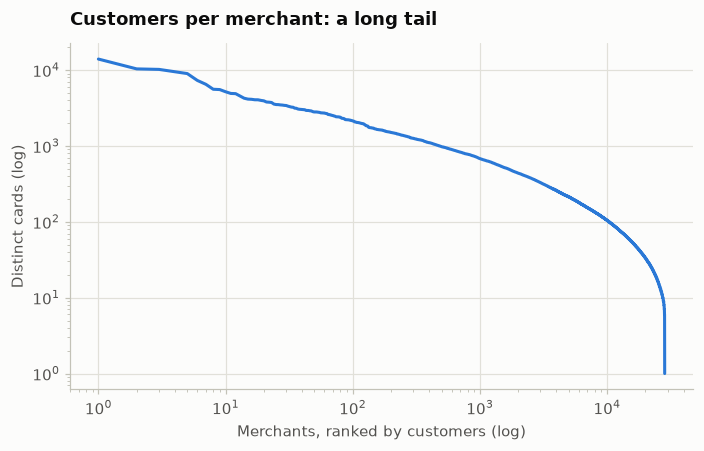

metric,value
str,str
"""cardholders""","""1.499e+05"""
"""merchants""","""3.052e+04"""
"""edges""","""4.262e+06"""
"""purchases""","""5.984e+06"""
"""density""","""0.0009315"""
"""mean_merchants_per_cardholder""","""28.43"""
"""median_customers_per_merchant""","""57"""


In [4]:
customers = np.sort(population["n_customers"].to_numpy())[::-1]
ranked = np.arange(1, len(customers) + 1)
fig, ax = plt.subplots(figsize=(6.5, 4.2))
ax.loglog(ranked, customers, color=SERIES[0])
ax.set_xlabel("Merchants, ranked by customers (log)")
ax.set_ylabel("Distinct cards (log)")
ax.set_title("Customers per merchant: a long tail")
fig.tight_layout()
plt.show()
pl.DataFrame(
    {
        "metric": list(stats),
        "value": [f"{value:,.4g}" for value in stats.values()],
    }
)

## 2. The comparison

One row per method. `eta2_*` is in-sample homogeneity, which always improves with more
segments, so it is read next to `burden_r2_oos`: how well a segment's average predicts the
relative burden of merchants held out of the fit. `nmi_mcc_group` says how much a
segmentation is the MCC group relabelled, and `nmi_clientele` compares it with the clientele
the generator planted — a diagnostic, never the criterion.

In [5]:
comparison.with_columns(
    pl.col("method").replace_strict(METHOD_LABEL).alias("method"), cs.float().round(3)
)

method,segments,coverage,largest_segment_share,eta2_interchange,eta2_burden,burden_r2_oos,burden_mae_ratio,burden_top_decile_lift,silhouette,nmi_mcc_group,nmi_clientele
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""Baseline (attributes)""",8.0,1.0,0.303,0.497,0.078,0.077,0.96,1.477,0.191,0.208,0.084
"""Graph (embeddings)""",12.0,1.0,0.119,0.403,0.015,0.011,0.991,1.068,0.184,0.035,0.373
"""Hybrid (attributes + graph)""",12.0,1.0,0.169,0.583,0.073,0.069,0.966,1.489,0.09,0.201,0.212
"""Leiden (communities)""",8.0,0.549,0.351,0.045,0.002,0.001,1.0,0.834,NaN,0.008,0.002


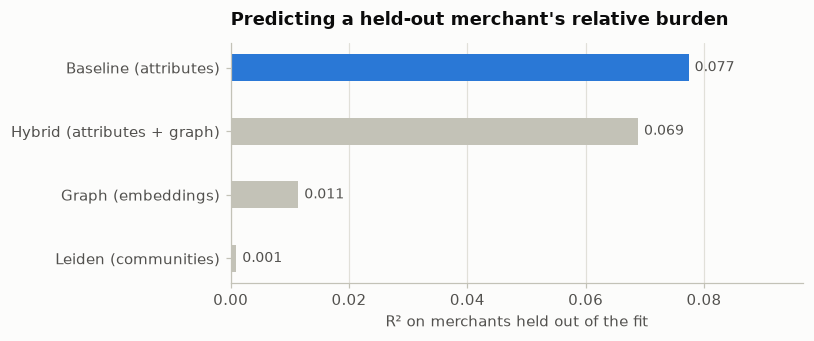

The graph segmentation does not beat the baseline on out-of-sample relative burden: R² 0.011 vs 0.077 (-0.066).
The hybrid segmentation does not beat the baseline on out-of-sample relative burden: R² 0.069 vs 0.077 (-0.009).


In [6]:
metric = "burden_r2_oos"
scores = comparison.select("method", metric).sort(metric, descending=True)
best = scores["method"].first()
colors = [SERIES[0] if m == best else AXIS for m in scores["method"]]
fig, ax = plt.subplots(figsize=(7.5, 3.2))
bars = ax.barh(
    [METHOD_LABEL[m] for m in scores["method"]], scores[metric], height=0.42, color=colors
)
ax.bar_label(bars, labels=[f"{v:.3f}" for v in scores[metric]], padding=4, color=INK_2, fontsize=9)
ax.invert_yaxis()
ax.set_xlim(0, max(scores[metric].max() * 1.25, 0.05))
ax.grid(axis="y", visible=False)
ax.set_xlabel("R² on merchants held out of the fit")
ax.set_title("Predicting a held-out merchant's relative burden")
fig.tight_layout()
plt.show()
print(run.verdict)
print(verdict(comparison, BASELINE, HYBRID))

### Is the verdict about the number of segments?

Each method picked its own k by silhouette, and they did not land on the same one. Sweeping k
for the three spaces answers the obvious objection: the graph is behind the attributes at
**every** number of segments, so the conclusion is not an artefact of that choice. It also
shows silhouette is not choosing the k a pricing team would want — the baseline is worth far
more at k=10 than at the k the silhouette picked.

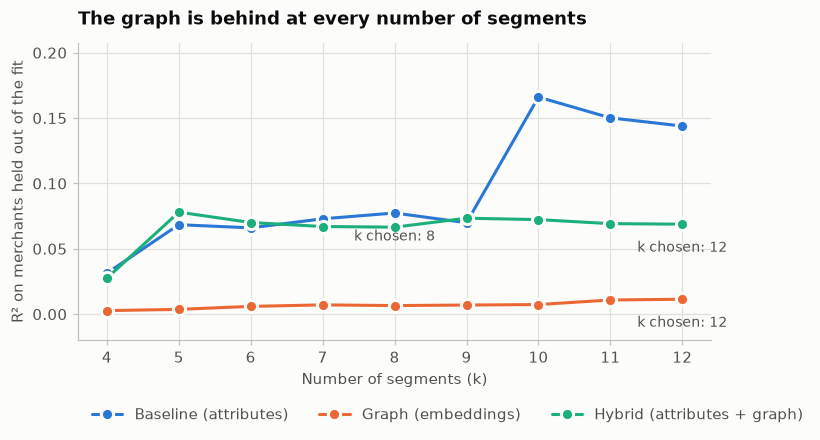

k,baseline,graph,hybrid
i64,f64,f64,f64
4,0.031,0.003,0.028
5,0.068,0.004,0.078
6,0.066,0.006,0.07
7,0.073,0.007,0.067
8,0.077,0.007,0.067
9,0.07,0.007,0.073
10,0.166,0.007,0.072
11,0.15,0.011,0.069
12,0.144,0.011,0.069


In [7]:
position = {int(m): i for i, m in enumerate(run.embedding.merchant_ids)}
rows = np.array([position[int(m)] for m in population["merchant_id"]])
vectors = run.embedding.vectors[rows]
tabular, _ = feature_matrix(population, cfg)
spaces = {BASELINE: tabular, GRAPH: vectors, HYBRID: combine_spaces(tabular, vectors)}
burden = population["relative_burden"].to_numpy()
ids = population["merchant_id"].to_numpy()
sweep = pl.DataFrame(
    [
        {
            "method": name,
            "k": k,
            "burden_r2_oos": out_of_sample(
                burden,
                cluster_merchants(name, ids, matrix, cfg, k=k).labels["segment"].to_numpy(),
                cfg,
            )["burden_r2_oos"],
        }
        for name, matrix in spaces.items()
        for k in cfg.segmentation.k_values
    ]
)
fig, ax = plt.subplots(figsize=(7.5, 4.2))
for i, (name, label) in enumerate((m, METHOD_LABEL[m]) for m in spaces):
    line = sweep.filter(pl.col("method") == name).sort("k")
    ax.plot(
        line["k"],
        line["burden_r2_oos"],
        color=SERIES[i],
        marker="o",
        markersize=8,
        markeredgecolor=SURFACE,
        markeredgewidth=2,
        label=label,
    )
    chosen = run.method(name).k
    point = line.filter(pl.col("k") == chosen)
    ax.annotate(
        f"k chosen: {chosen}",
        xy=(chosen, point["burden_r2_oos"].item()),
        xytext=(0, -18),
        textcoords="offset points",
        ha="center",
        color=INK_2,
        fontsize=9,
    )
ax.set_xticks(list(cfg.segmentation.k_values))
ax.set_xlabel("Number of segments (k)")
ax.set_ylabel("R² on merchants held out of the fit")
ax.set_ylim(-0.02, max(sweep["burden_r2_oos"].max() * 1.25, 0.05))  # aire para las anotaciones
ax.set_title("The graph is behind at every number of segments")
ax.legend(loc="upper left", bbox_to_anchor=(0, -0.18), ncol=3)
fig.tight_layout()
plt.show()
sweep.pivot(on="method", index="k", values="burden_r2_oos").sort("k").with_columns(
    cs.float().round(3)
)

## 3. Homogeneity: how much variation each segmentation explains

Effective interchange is weighted by volume, because that is where the network's revenue
sits; relative burden is per merchant, because dropping acceptance is a per-merchant
decision. Leiden is free to use as many communities as it likes, so its in-sample numbers are
not comparable to the two k-means at face value.

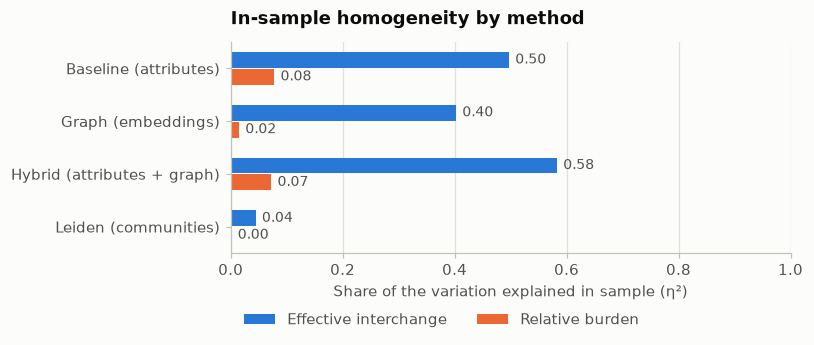

method,segments,coverage,largest_segment_share,eta2_interchange,eta2_burden,burden_r2_oos,burden_mae_ratio,burden_top_decile_lift
str,f64,f64,f64,f64,f64,f64,f64,f64
"""Baseline (attributes)""",8.0,1.0,0.303,0.497,0.078,0.077,0.96,1.477
"""Graph (embeddings)""",12.0,1.0,0.119,0.403,0.015,0.011,0.991,1.068
"""Hybrid (attributes + graph)""",12.0,1.0,0.169,0.583,0.073,0.069,0.966,1.489
"""Leiden (communities)""",8.0,0.549,0.351,0.045,0.002,0.001,1.0,0.834


In [8]:
metrics = [("eta2_interchange", "Effective interchange"), ("eta2_burden", "Relative burden")]
methods = comparison["method"].to_list()
y = np.arange(len(methods))
fig, ax = plt.subplots(figsize=(7.5, 3.4))
for i, (column, label) in enumerate(metrics):
    bars = ax.barh(
        y + (i - 0.5) * 0.32, comparison[column], height=0.3, color=SERIES[i], label=label
    )
    ax.bar_label(
        bars, labels=[f"{v:.2f}" for v in comparison[column]], padding=4, color=INK_2, fontsize=9
    )
ax.set_yticks(y, [METHOD_LABEL[m] for m in methods])
ax.invert_yaxis()
ax.set_xlim(0, 1)
ax.grid(axis="y", visible=False)
ax.set_xlabel("Share of the variation explained in sample (η²)")
ax.set_title("In-sample homogeneity by method")
ax.legend(loc="upper left", bbox_to_anchor=(0, -0.22), ncol=2)
fig.tight_layout()
plt.show()
comparison.select(
    pl.col("method").replace_strict(METHOD_LABEL).alias("method"),
    "segments",
    "coverage",
    "largest_segment_share",
    "eta2_interchange",
    "eta2_burden",
    "burden_r2_oos",
    "burden_mae_ratio",
    "burden_top_decile_lift",
).with_columns(cs.float().round(3))

## 4. What the segments are made of

Each cell is the share of a segment's volume that comes from one MCC group. The baseline is
MCC by construction; the graph is free to cut across categories when the same cards buy from
both sides.

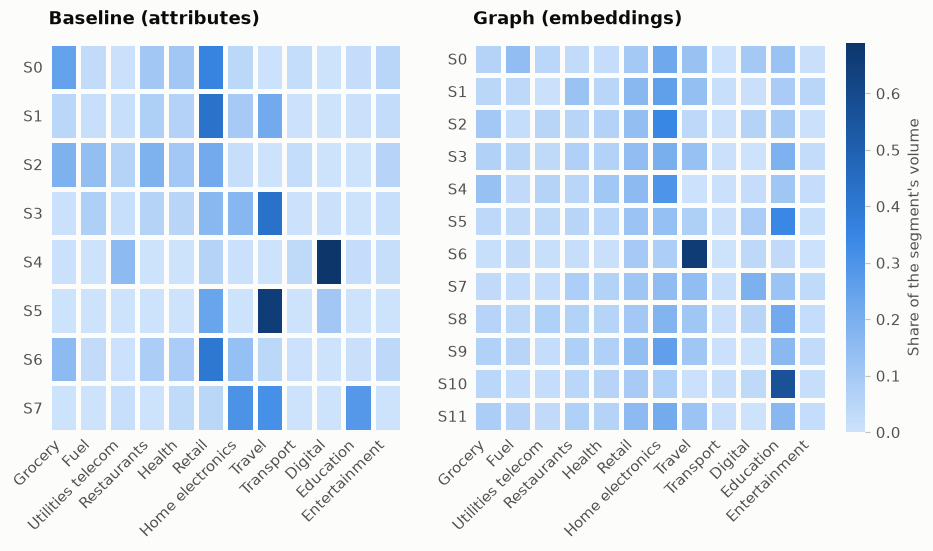

In [9]:
def mix(method):
    labels = run.method(method).labels
    joined = population.join(labels, on="merchant_id").filter(pl.col("segment") >= 0)
    share = (
        joined.group_by("segment", pl.col("mcc_group").cast(pl.Utf8))
        .agg(pl.col("gdv_cop").sum())
        .with_columns((pl.col("gdv_cop") / pl.col("gdv_cop").sum().over("segment")).alias("share"))
    )
    groups = list(cfg.group_names)
    segments = sorted(share["segment"].unique().to_list())
    matrix = np.zeros((len(segments), len(groups)))
    for row, group, value in share.select("segment", "mcc_group", "share").iter_rows():
        matrix[segments.index(row), groups.index(group)] = value
    return matrix, segments, groups


blues = LinearSegmentedColormap.from_list("blues", BLUES)
panels = {method: mix(method) for method in (BASELINE, GRAPH)}
# Misma escala en los dos paneles, ajustada al máximo real: si llega a 1 todo se ve pálido.
top = max(matrix.max() for matrix, _, _ in panels.values())
fig, axes = plt.subplots(1, 2, figsize=(11, 4.6), width_ratios=[1, 1])
for ax, method in zip(axes, panels, strict=True):
    matrix, segments, groups = panels[method]
    mesh = ax.pcolormesh(matrix, cmap=blues, edgecolors=SURFACE, linewidth=2, vmin=0, vmax=top)
    ax.set_xticks(
        np.arange(len(groups)) + 0.5, [pretty(g) for g in groups], rotation=45, ha="right"
    )
    ax.set_yticks(np.arange(len(segments)) + 0.5, [f"S{s}" for s in segments])
    ax.invert_yaxis()
    ax.grid(False)
    ax.tick_params(length=0)
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.set_title(METHOD_LABEL[method])
bar = fig.colorbar(mesh, ax=axes, pad=0.02)
bar.outline.set_visible(False)
bar.set_label("Share of the segment's volume", color=INK_2)
plt.show()

## 5. The segments as a business table

The profile of the graph segmentation: what each segment sells, what it pays and how heavy
that payment is against its margin. This is the table a pricing memo carries.

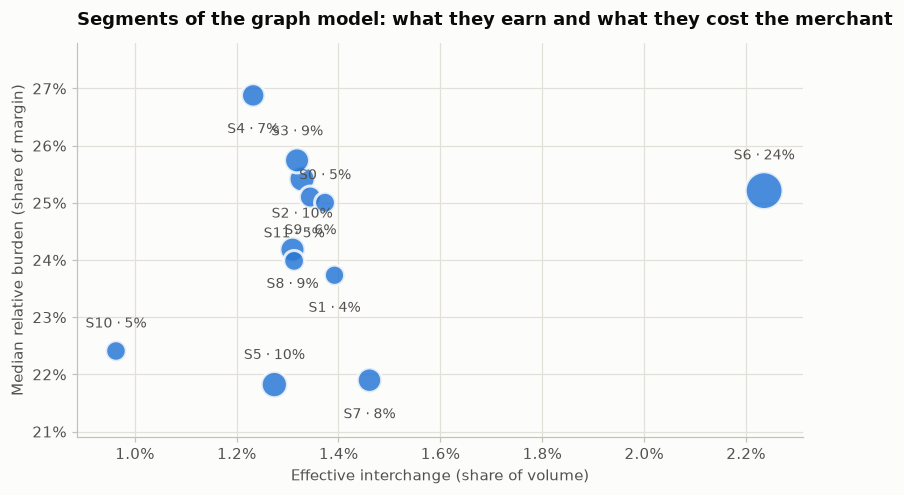

segment,merchants,volume_share,avg_ticket_cop,effective_interchange_rate,effective_mdr_rate,median_relative_burden,p90_relative_burden,cnp_share,cross_border_share,top_mcc_group,top_city,top_size_tier
i32,i64,f64,f64,f64,f64,f64,f64,f64,f64,str,str,str
6,"3,296",0.2416,"347,145.2622",0.0224,0.0272,0.2521,0.613,0.6386,0.1893,"""travel, retail, home_electronics""","""bogota, other""","""small, medium, large"""
5,"3,012",0.0981,"171,716.5759",0.0127,0.018,0.2182,0.5409,0.3515,0.0032,"""education, home_electronics, retail""","""other, cali""","""medium, small, micro"""
2,"3,380",0.0963,"132,084.909",0.0133,0.0193,0.2542,0.6155,0.3007,0.0016,"""home_electronics, retail, grocery""","""other, medellin""","""small, medium, micro"""
8,"2,542",0.0859,"144,853.033",0.0131,0.0188,0.2418,0.5864,0.3212,0.0016,"""education, home_electronics, travel""","""cartagena, cucuta, bucaramanga""","""medium, small, large"""
3,"2,824",0.0853,"150,759.7054",0.0132,0.0191,0.2574,0.6056,0.2028,0.0,"""home_electronics, education, retail""","""medellin, other""","""small, medium, micro"""
7,"2,510",0.0801,"139,307.5125",0.0146,0.0206,0.219,0.4927,0.4494,0.012,"""digital, home_electronics, travel""","""other, bogota""","""medium, small, micro"""
4,"2,647",0.0703,"121,895.0708",0.0123,0.0185,0.2688,0.6112,0.1956,0.0,"""home_electronics, retail, grocery""","""bogota""","""small, medium, micro"""
9,"2,030",0.0576,"144,047.0057",0.0134,0.0194,0.251,0.5883,0.1789,0.0001,"""home_electronics, education, retail""","""cali, bogota""","""small, medium, micro"""
0,"1,447",0.048,"151,518.4303",0.0137,0.0194,0.25,0.6125,0.348,0.0011,"""home_electronics, fuel, travel""","""other, bogota""","""medium, small, large"""


In [10]:
profiles = run.profiles
fig, ax = plt.subplots(figsize=(7.5, 4.6))
sizes = profiles["volume_share"].to_numpy()
ax.scatter(
    profiles["effective_interchange_rate"],
    profiles["median_relative_burden"],
    s=80 + 2200 * sizes,
    color=SERIES[0],
    alpha=0.85,
    edgecolors=SURFACE,
    linewidths=2,
    zorder=3,
)
labelled = profiles.select(
    "segment", "effective_interchange_rate", "median_relative_burden", "volume_share"
).sort("median_relative_burden")
for index, (segment, x, y, share) in enumerate(labelled.iter_rows()):
    # Etiquetas alternadas arriba y abajo: los segmentos se apilan en el centro del gráfico.
    above = index % 2 == 0
    offset = 12 + 26 * share
    ax.annotate(
        f"S{segment} · {share:.0%}",
        xy=(x, y),
        xytext=(0, offset if above else -offset - 4),
        textcoords="offset points",
        ha="center",
        va="bottom" if above else "top",
        color=INK_2,
        fontsize=9,
    )
ax.margins(x=0.06, y=0.18)  # aire para las etiquetas, que van fuera de los puntos
ax.xaxis.set_major_formatter(PercentFormatter(1.0, decimals=1))
ax.yaxis.set_major_formatter(PercentFormatter(1.0, decimals=0))
ax.set_xlabel("Effective interchange (share of volume)")
ax.set_ylabel("Median relative burden (share of margin)")
ax.set_title("Segments of the graph model: what they earn and what they cost the merchant")
fig.tight_layout()
plt.show()
profiles.with_columns(cs.float().round(4))

## 6. Diagnostic: is this just the MCC, or the planted clientele?

`nmi_mcc_group` measures how much each segmentation repeats the merchant category;
`nmi_clientele` compares it with the latent clientele the generator planted. The second is a
check on the generator and on the method's ability to find structure, not evidence about any
real market.

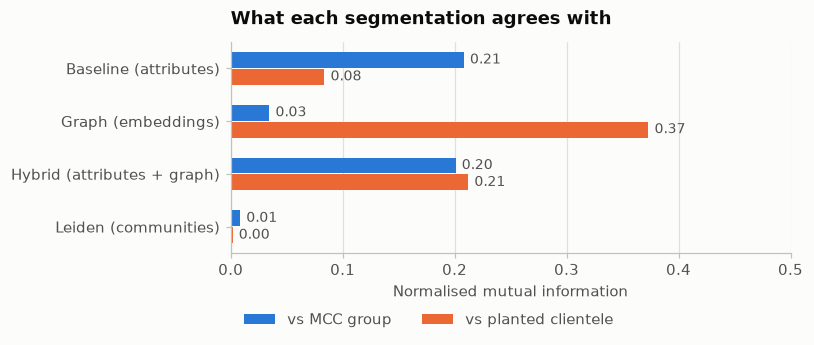

In [11]:
diagnostics = [("nmi_mcc_group", "vs MCC group"), ("nmi_clientele", "vs planted clientele")]
y = np.arange(len(methods))
fig, ax = plt.subplots(figsize=(7.5, 3.4))
for i, (column, label) in enumerate(diagnostics):
    bars = ax.barh(
        y + (i - 0.5) * 0.32, comparison[column], height=0.3, color=SERIES[i], label=label
    )
    ax.bar_label(
        bars, labels=[f"{v:.2f}" for v in comparison[column]], padding=4, color=INK_2, fontsize=9
    )
ax.set_yticks(y, [METHOD_LABEL[m] for m in methods])
ax.invert_yaxis()
ax.set_xlim(0, max(0.5, comparison["nmi_mcc_group"].max() * 1.3))
ax.grid(axis="y", visible=False)
ax.set_xlabel("Normalised mutual information")
ax.set_title("What each segmentation agrees with")
ax.legend(loc="upper left", bbox_to_anchor=(0, -0.22), ncol=2)
fig.tight_layout()
plt.show()

## Limits

- **The clienteles were planted.** The generator built the structure the graph is looking
  for, so recovering it proves the method works on this data, not that real merchants cluster
  this way.
- **Relative burden is a stand-in for churn.** Feature 5 brings the acceptance curve; the
  same comparison will then carry the real churn metric.
- **Embeddings are spectral, not node2vec.** PPMI plus truncated SVD is the matrix
  factorisation that random-walk embeddings approximate (Qiu et al., 2018), chosen because it
  is deterministic and reproducible in seconds.
- **In-sample homogeneity rewards more segments.** Leiden picks its own number of
  communities, so its η² is not comparable with the k-means methods at face value; the
  out-of-sample column is.
- **Silhouette picks k without knowing the business question.** The sweep shows the baseline
  is worth twice as much at k=10 as at the k silhouette chose. Choosing k by the business
  metric would be the next step, and would need its own held-out split to stay honest.

In [12]:
print(f"Notebook runtime: {time.perf_counter() - start:.1f} s")

Notebook runtime: 73.1 s
